## Day 6 – Data & Domain

### Use Case
*Focus: domain and application context*

> In the context of **financial time series analysis**, one-dimensional price signals generated by the Swiss Market Index (SMI) are recorded daily using the SIX Swiss Exchange electronic order book in order to detect recurring market cycles and identify characteristic price patterns.  
> The resulting digital signals are analyzed by **portfolio managers and quantitative analysts** to perform trend detection, mean-reversion analysis, and market regime identification.  
> This use case is particularly relevant for **Switzerland** because the SMI, comprising the 20 largest Swiss companies, exhibits well-documented cyclical behavior driven by weekly trading patterns, monthly fund rebalancing, and quarterly earnings announcements — all of which produce recurring structures in the daily price signal.

### Problem Statement
*Focus: technical vulnerability*

> This project addresses the problem of applying **auto-correlation and cross-correlation analysis** to the SMI daily closing price signal within the context of market cycle detection and pattern recognition in the Swiss financial market.  
> If periodicity detection fails due to inappropriate lag selection or insufficient signal length, dominant market cycles may be overlooked, leading to missed trading opportunities or incorrect volatility forecasts. Similarly, if cross-correlation-based template matching is too sensitive to noise or amplitude variation, pattern detection becomes unreliable, producing false positives that misguide trading decisions.  
> Preserving the ability to **detect recurring weekly and monthly patterns** while reliably **locating specific signal segments** is essential for systematic financial analysis in this use case.

### Experimental Objective
*Focus: investigation goal at the conceptual level*

> The objective of this project is to investigate how effectively auto-correlation reveals recurring temporal structures (weekly, monthly cycles) in the SMI daily price signal, and how reliably cross-correlation localizes a specific price pattern within the full annual signal. The goal is to understand under which conditions correlation-based methods provide stable and actionable insights in the context of financial market analysis.

### Data Definition, Source, and Visualization
*Focus: data characteristics, data source, and visual inspection*

> The selected signal represents **daily closing prices of the Swiss Market Index (SMI)** over one trading year, generated by market-aggregated trade executions on the SIX Swiss Exchange, measured using the electronic order book, and expressed in **CHF**.  
> Its relevant characteristics include **periodic structures driven by the 5-day trading week, monthly fund rebalancing (~22 trading days), and quarterly earnings cycles (~65 trading days)**, which are important for detecting recurring market patterns and assessing trend persistence.  
> The data originate from the **Yahoo Finance API** (ticker: ^SSMI), provided by Yahoo/ICE Data Services, and are appropriate because they provide standardized, publicly available daily price data under documented market conditions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.signal import find_peaks

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [2]:
smi_daily = yf.download("^SSMI", period="1y", interval="1d", progress=False)
if isinstance(smi_daily.columns, pd.MultiIndex):
    smi_daily.columns = smi_daily.columns.get_level_values(0)

price = smi_daily['Close'].dropna().values.astype(float)
time_index = smi_daily['Close'].dropna().index

print(f"Data points: {len(price)} trading days")
print(f"Time span: {time_index[0].strftime('%Y-%m-%d')} to {time_index[-1].strftime('%Y-%m-%d')}")

/var/folders/qr/40kwqhb578jfzhtt2nw831h40000gn/T/ipykernel_39433/2993386528.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  smi_daily = yf.download("^SSMI", period="1y", interval="1d", progress=False)


Data points: 249 trading days
Time span: 2025-03-17 to 2026-03-16


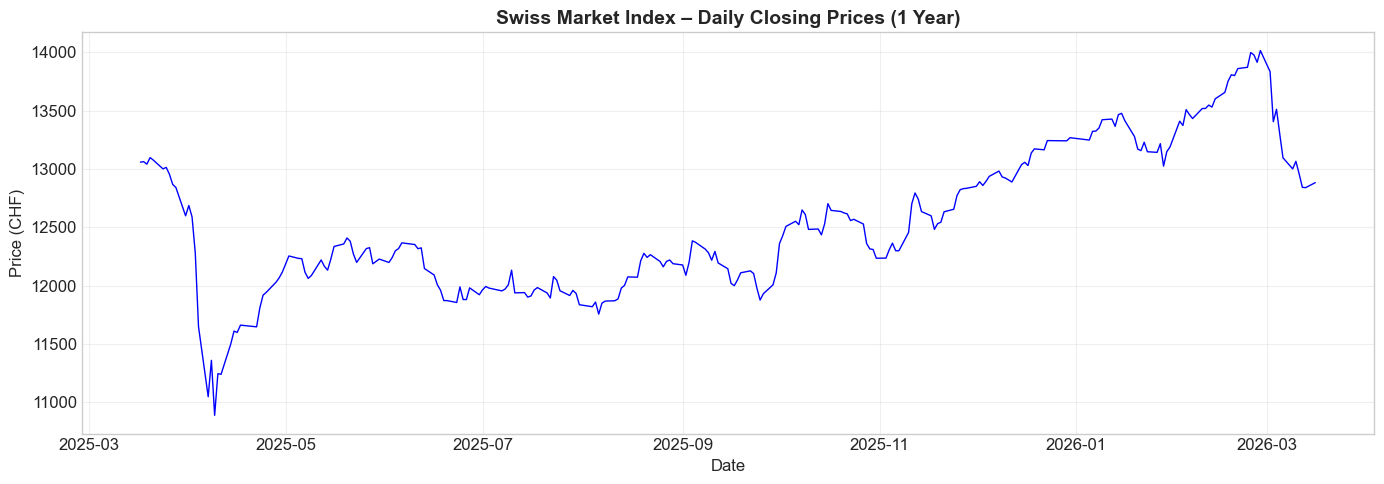

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_index, price, 'b-', linewidth=1)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (CHF)', fontsize=12)
ax.set_title('Swiss Market Index – Daily Closing Prices (1 Year)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observations:**
> The visualization illustrates the SMI daily closing price over one trading year, with notable trend components and shorter-term oscillations visible. This time series was selected because it clearly highlights the expected recurring weekly and monthly structures relevant to the defined correlation analysis use case.